!pip install pandasql

In [1]:
import pandas as pd
import pandasql as psql
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
def graficoBarApiladas(data,variable,y):
    # Crear una tabla de contingencia
    contingency = pd.crosstab(data[variable], data[y])

    # Crear el gráfico de barras apiladas
    contingency.plot(kind='bar', stacked=True, colormap='viridis')

    # Añadir etiquetas y título
    plt.xlabel(variable)
    plt.ylabel('%')
    plt.title('Grafico '+variable+'  '+ y)

    # Mostrar el gráfico
    plt.show()
    
def targetToBinary(r):
    if r['Target']=='yes':
        return 1
    return 0    

In [88]:
marketing = pd.read_csv('data/bank-full.csv',sep=',')

Convertimos el target a binario

In [89]:
marketing['y']=marketing.apply(targetToBinary,axis=1)

In [39]:
consulta ='SELECT * FROM marketing'

rs = psql.sqldf(consulta,locals())

In [40]:
rs.head(2)

,age,job,marital,education,default_,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


In [41]:
rs.Target.value_counts()

no     39922
yes     5289
Name: Target, dtype: int64

### Datos demográficos

a. ¿ Cuál es la edad media de los clientes con estado civil "married"?

In [21]:
consulta ="   "

rs = psql.sqldf(consulta,locals())

In [22]:
rs

,round(avg(age))
0,43.0


b. ¿ Como se distribuye el estado civil de los clientes de 31 años?

In [25]:
consulta ="  "

rs = psql.sqldf(consulta,locals())

In [26]:
rs

,marital,n
0,divorced,98
1,married,881
2,single,1017


### Datos financieros

a. De los clientes que tienen un préstamo Hipotecario, ¿cuántos tienen un préstamo personal?

In [27]:
consulta ="  "

rs = psql.sqldf(consulta,locals())

In [ ]:
rs

b. ¿Cuantos de los clientes con profesión "management" tienen un balance anual positivo?

In [29]:
consulta =" "

rs = psql.sqldf(consulta,locals())

In [30]:
rs

,n
0,8053


c. ¿Cuántos de los clientes con educación "Tertiary" tienen un crédito en default?

In [42]:
consulta =""

rs = psql.sqldf(consulta,locals())

In [43]:
rs

,n
0,198


### Contactos de campañas

a. ¿Cuanto es el número de contactos medio de la campaña actual de los clientes contactados por última vez en mayo?

In [44]:
consulta =""

rs = psql.sqldf(consulta,locals())

In [45]:
rs

,campaign_avg
0,2.447552


b.¿Son los clientes contactados en junio, los que muestran una mayor duración media?

In [47]:
consulta =""
rs = psql.sqldf(consulta,locals())

In [48]:
rs

,month,campaign_avg
0,apr,1.955321
1,aug,3.927325
2,dec,2.196262
3,feb,2.382031
4,jan,1.672131
5,jul,3.524438
6,jun,3.135368
7,mar,2.205451
8,may,2.447552
9,nov,1.918136


### Deposito a Plazo

a.- Independiemtemente del "estado civil" del cliente, la proporción de contratación de depósito a 
plazo no cambia, siempre es la misma. ¿esta afirmación es correcta?


In [55]:
consulta ="""            """
rs = psql.sqldf(consulta,locals())   

In [56]:
rs

,total_deposito
0,5289


In [83]:
consulta ="""
            """
rs = psql.sqldf(consulta,locals())    


In [84]:
rs

,marital,n_depositos,t_depositos,rto_depositos,rto_depo
0,divorced,622,5289,0,0.117603
1,married,2755,5289,0,0.520892
2,single,1912,5289,0,0.361505


b.- Observa la tenencia de hipoteca, ¿ crees que es una variable útil para predecir si un cliente puede contratar un Depósito a plazo ?

In [85]:
consulta ="""
            """
rs = psql.sqldf(consulta,locals())    


In [86]:
rs

,housing,n_depositos,t_depositos,rto_depositos,rto_depo
0,no,3354,5289,0,0.634146
1,yes,1935,5289,0,0.365854


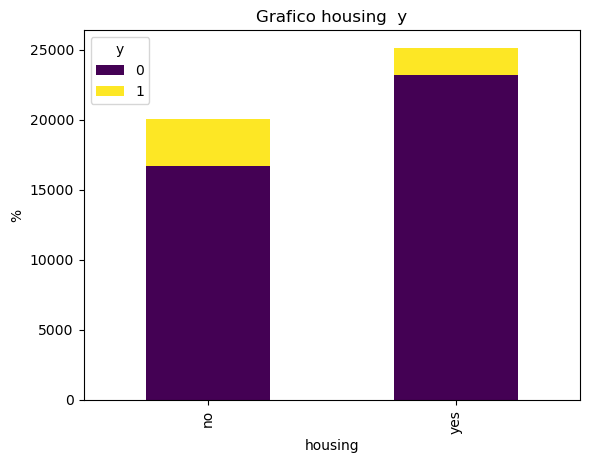

In [90]:
graficoBarApiladas(marketing,'housing','y')

c.¿Podríamos asumir que, a mayor duración de la llamada, hay mayor probabilidad de contratar un 
depósito a plazo (target='yes')?

In [99]:
consulta ="""  """
rs = psql.sqldf(consulta,locals())    


In [100]:
rs

,decil,n_depositos
0,1,9
1,2,50
2,3,130
3,4,205
4,5,307
5,6,411
6,7,558
7,8,619
8,9,945
9,10,2055


In [107]:
consulta =""" """
rs = psql.sqldf(consulta,locals())   

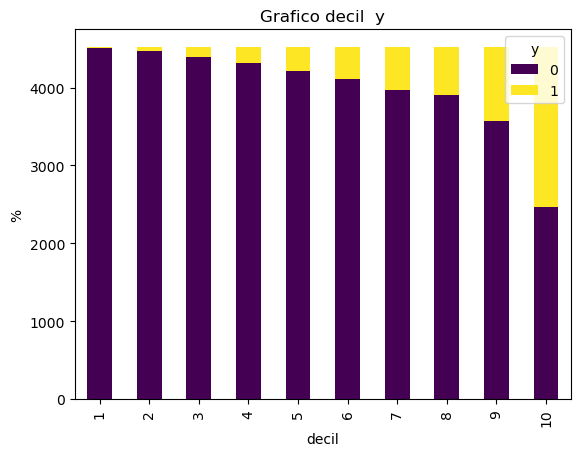

In [109]:
graficoBarApiladas(rs,'decil','y')

### Information Value (IV) 

Information Value (IV) es una medida utilizada en el análisis predictivo para evaluar la importancia de una variable independiente en la predicción de una variable dependiente binaria (por ejemplo, riesgo crediticio). Aquí tienes una función en Python que calcula el Information Value para una variable categórica:

In [17]:
def calculate_iv(data, feature, target):
    """
    Calcula el Information Value (IV) para una variable categórica.
    
    Parameters:
    - data: DataFrame que contiene los datos.
    - feature: El nombre de la columna de la variable categórica.
    - target: El nombre de la columna de la variable dependiente binaria.
    
    Returns:
    - iv: El valor de IV para la variable especificada.
    """
    # Crear una tabla de frecuencia para la variable y el target
    freq_table = pd.crosstab(data[feature], data[target])
    
    # Calcular las proporciones de buenos y malos
    freq_table['good'] = freq_table[0] / freq_table[0].sum()
    freq_table['bad'] = freq_table[1] / freq_table[1].sum()
    
    # Calcular el WoE (Weight of Evidence) y el IV para cada categoría
    freq_table['WoE'] = np.log(freq_table['good'] / freq_table['bad'])
    freq_table['IV']  = (freq_table['good'] - freq_table['bad']) * freq_table['WoE']
    
    # Sumar el IV total
    iv = freq_table['IV'].sum()
    
    return iv

def histograma(data,variable,bins=30):
    #histograma
    sns.histplot(data[variable], bins=bins, kde=True)

    # Añadir etiquetas y título
    plt.xlabel('Valor de '+variable)
    plt.ylabel('Frecuencia')
    plt.title('Histograma de '+variable)

    # Mostrar el gráfico
    plt.show()
    


Calculamos el IV para una variable categórica

In [12]:
iv_value = calculate_iv(marketing, 'loan', 'y')
print(f"Information Value: {iv_value}")

Information Value: 0.054858526982233244


Calculamos el IV para una variable continua

In [14]:
#creamos 10 bines y la convertimos a  categorica
marketing['balance_bin'] = pd.qcut(marketing['balance'], q=10, labels=False)
iv_value      = calculate_iv(marketing, 'balance_bin', 'y')
print(f"Information Value: {iv_value}")

Information Value: 0.1019386058018926
